# Cascata hidrelétrica sintética

Este notebook usa exclusivamente dados e parâmetros fictícios. A configuração-base e a pasta de saída são encontradas automaticamente pelo pacote experimental.

## Variáveis e convenções

O horizonte possui 24 períodos horários. O índice $t$ identifica o período, $u$ identifica a usina e as usinas são A (montante) e B (jusante). A água defluída por A no período $t-1$ chega a B no período $t$.

| Símbolo | Unidade | Significado |
| --- | --- | --- |
| $y_{u,t}$ | m³/s | Afluência incremental, isto é, a água que chega naturalmente à usina. |
| $I_{u,t}$ | m³/s | Afluência total disponível para a usina. Em B inclui a chegada da defluência de A. |
| $Q_{u,t}$ | m³/s | Vazão efetivamente turbinada; converte energia hidráulica em elétrica. |
| $S_{u,t}$ | m³/s | Vazão vertida; sai pelo vertedouro sem gerar energia. |
| $S^{san}_{u,t}$ | m³/s | Parcela sanitária fixa, liberada somente se o nível provisório superar o máximo. |
| $S^{cap}_{u,t}$ | m³/s | Parcela automática de vertimento devido à capacidade máxima de turbinamento. |
| $D_{u,t}$ | m³/s | Defluência total: soma da vazão turbinada e da vazão vertida. |
| $V_{u,t}$ | hm³ | Volume armazenado no reservatório no início do período. |
| $V^{maximorum}_u$ | hm³ | Limite de armazenamento excepcional que aciona o vertimento de emergência. |
| $n^{maximorum}_u$ | m | Nível excepcional associado ao volume maximorum. |
| $n^{up}_{u,t}$ | m | Nível de montante, calculado a partir do volume do reservatório. |
| $n^{down}_{u,t}$ | m | Nível de jusante, calculado a partir da defluência total. |
| $H_{u,t}$ | m | Queda líquida: diferença entre montante e jusante, limitada a zero. |
| $P_{u,t}$ | MW | Potência elétrica gerada no período. |
| $z_{u,t}$ | 0 ou 1 | Estado da turbina agregada: desligada ou ligada. |
| $d_{u,t}$ | h | Tempo consecutivo no estado atual da turbina agregada. |
| $E$ | MWh | Energia gerada ao longo do horizonte. |
| $\eta_u$ | — | Rendimento global constante e sintético da usina. |

As variáveis de decisão do otimizador são as vazões solicitadas para A e B em cada período. O simulador as transforma em vazões turbinadas viáveis, calcula vertimento, atualiza os reservatórios e devolve a energia, as penalidades de nível e a penalidade de chaveamento.

## Modelo simplificado

A cascata possui duas usinas fictícias: A, a montante, e B, a jusante. A defluência de A chega a B após um período horário. O objetivo é fornecer uma base acadêmica reproduzível, não reproduzir a operação de um sistema real.

### O que foi preservado

Foram preservados o balanço de massa, a propagação em cascata, a dependência do nível de montante em relação ao volume, a dependência do nível de jusante em relação à defluência, a queda líquida, os limites básicos de potência e a penalidade de nível.

### O que foi simplificado

Há somente duas usinas fictícias, uma turbina agregada por usina e períodos horários. As afluências são sintéticas; $y_{B,t}$ agrega todas as contribuições locais de B. Os polinômios de nível são sintéticos e normalizados. Não há múltiplas máquinas, curvas de colina, perdas hidráulicas explícitas, tempos mínimos de operação, rampas, custos, preços, restrições elétricas, calibração com dados reais ou regras operacionais proprietárias.

### Afluência e defluência

Afluência total em A:

$$I_{A,t}=y_{A,t}$$

Afluência total em B:

$$I_{B,t}=y_{B,t}+D_{A,t-1}$$

Defluência total de cada usina:

$$D_{u,t}=Q_{u,t}+S_{u,t}$$

### Balanço hídrico e vertimento

Atualização do volume armazenado:

$$V_{u,t+1}=V_{u,t}+\Delta V(I_{u,t}-Q_{u,t}-S_{u,t})$$

Conversão de vazão para volume, por período horário:

$$\Delta V=\frac{3600}{10^6}$$

Primeiro calcula-se o nível provisório sem vertimento. Se ele não superar $n^{max}_u$, então todas as parcelas de vertimento são nulas.

Vertimento sanitário fixo, aplicado somente quando o nível provisório supera o máximo:

$$S^{san}_{u,t}=S^{san}_u$$

Vertimento automático pela capacidade máxima de turbinamento:

$$S^{cap}_{u,t}=\max(0,I_{u,t}-Q_u^{max})$$

Volume provisório, antes do controle gradual de nível:

$$V^*_{u,t+1}=V_{u,t}+\Delta V(I_{u,t}-Q_{u,t}-S^{san}_{u,t}-S^{cap}_{u,t})$$

Vertimento por curva de nível dentro da faixa entre o máximo normal e o maximorum:

$$r^n_{u,t}=\frac{(n^{up,*}_{u,t+1}-n_u^{max})_+}{n_u^{maximorum}-n_u^{max}}$$

$$S^{lvl}_{u,t}=\sigma_u Q_u^{max}\min(1,r^n_{u,t})^{\nu_u}+\sigma_u Q_u^{max}(r^n_{u,t}-1)_+^2$$

Vertimento total:

$$S_{u,t}=S^{san}_{u,t}+S^{cap}_{u,t}+S^{lvl}_{u,t}$$

### Níveis, queda e geração

Volume normalizado do reservatório na faixa completa até o maximorum:

$$x=\frac{V-V^{min}}{V^{maximorum}-V^{min}}$$

Nível de montante por polinômio sintético de quarto grau:

$$n^{up}=n^{min}+(n^{maximorum}-n^{min})\sum_{k=0}^{4}a_kx^k$$

Os coeficientes normalizados são sintéticos e calibrados para atravessar os pontos $(V^{max},n^{max})$ e $(V^{maximorum},n^{maximorum})$, sem copiar coeficientes de usinas reais.

Nível de jusante por polinômio sintético de quarto grau, com $z=(Q+S)/Q^{max}$:

$$n^{down}=a^{down}+r^{down}\sum_{k=0}^{4}b_kz^k$$

Queda líquida:

$$H=\max(0,n^{up}-n^{down})$$

Potência elétrica, com $g=9{,}81\ \mathrm{m/s^2}$:

$$P=0{,}00981\,\eta H Q$$

Penalidade de chaveamento da turbina agregada, para cada transição entre horas:

$$C^{sw}_{u,t}=w^{sw}|z_{u,t}-z_{u,t-1}|,\quad t>0$$

Penalidade adicional caso a troca ocorra antes de oito horas no estado anterior:

$$C^{early}_{u,t}=w^{early}\max(0,8-d_{u,t-1})|z_{u,t}-z_{u,t-1}|$$

A função objetivo minimizada pelo GIVP é a energia com sinal negativo, as penalidades quadráticas de nível e a penalidade de chaveamento:

$$F=-E+\sum_{u,t}(C^-_{u,t}+C^+_{u,t}+C^{sw}_{u,t}+C^{early}_{u,t})$$

Assim, desligar e religar uma turbina em horas consecutivas recebe duas penalidades de chaveamento e duas penalidades de permanência mínima. A regra é suave: o otimizador ainda pode fazê-lo se isso for mais vantajoso para a segurança hídrica.

## 1. Imports

Carrega apenas bibliotecas do experimento, o otimizador GIVP e as funções do modelo sintético. Não há acesso a dados reais ou a caminhos externos ao projeto.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from givp import GIVPConfig, givp
from IPython.display import Markdown, display
from synthetic_hydropower.benchmark import save_benchmark_results
from synthetic_hydropower.model import CascadeConfig, PlantConfig, simulate_cascade
from synthetic_hydropower.paths import default_config_path, default_output_dir
from synthetic_hydropower.scenarios import ScenarioDefinition, generate_inflows

## 2. Configuração da cascata

Lê os parâmetros fictícios das duas usinas e fixa o horizonte de 24 horas, o atraso hidráulico e os pesos de penalidade de nível e de chaveamento.

In [2]:
config_path = default_config_path()
output_dir = default_output_dir()
plant_payload = json.loads(config_path.read_text(encoding="utf-8"))
plants = tuple(PlantConfig(**plant) for plant in plant_payload["plants"])
cascade = CascadeConfig(
    plants=(plants[0], plants[1]),
    periods=24,
    period_hours=1.0,
    travel_time_steps=1,
    level_penalty_weight=10_000.0,
    unit_switch_penalty_weight=250.0,
    minimum_state_duration_hours=8,
    early_switch_penalty_weight=500.0,
)

## 3. Cenários de afluência

Define sete regimes sintéticos para testar situações secas, típicas, de pico e de cheia. Cada cenário será gerado com uma seed fixa.

In [3]:
scenarios = {
    "dry_stable": ScenarioDefinition("dry_stable", 75.0, 22.0, 0.03, "stable"),
    "dry_variable": ScenarioDefinition(
        "dry_variable", 100.0, 28.0, 0.16, "alternating"
    ),
    "typical": ScenarioDefinition("typical", 180.0, 60.0, 0.10, "daily"),
    "upstream_peak": ScenarioDefinition("upstream_peak", 250.0, 45.0, 0.12, "peak"),
    "downstream_dominant": ScenarioDefinition(
        "downstream_dominant", 140.0, 145.0, 0.10, "daily"
    ),
    "wet_rising": ScenarioDefinition("wet_rising", 240.0, 90.0, 0.08, "rising"),
    "flood": ScenarioDefinition("flood", 390.0, 155.0, 0.12, "peak"),
}

## 4. Hiperparâmetros do GIVP

Usa os valores finais documentados na dissertação para a busca do GIVP. Eles orientam o experimento sintético, mas não transferem dados, regras ou o orçamento de tempo do problema real.

In [4]:
optimizer_parameters = {
    "max_iterations": 40,
    "alpha": 0.17,
    "vnd_iterations": 15,
    "ils_iterations": 5,
    "perturbation_strength": 8,
    "use_elite_pool": True,
    "elite_size": 4,
    "path_relink_frequency": 10,
    "num_candidates_per_step": 15,
    "use_cache": True,
    "cache_size": 10_000,
    "use_convergence_monitor": True,
}
print(f"Serão executados {len(scenarios)} cenários: {', '.join(scenarios)}")
output_dir.mkdir(parents=True, exist_ok=True)

Serão executados 7 cenários: dry_stable, dry_variable, typical, upstream_peak, downstream_dominant, wet_rising, flood


## 5. Otimização e salvamento incremental

Executa cada cenário com seed própria. Ao terminar cada um, atualiza os CSVs e o manifesto JSON em `output/`; assim, resultados já concluídos não se perdem se a execução for interrompida.

In [5]:
def optimize_scenario(definition: ScenarioDefinition, seed: int):
    inflows = generate_inflows(definition, cascade.periods, seed)
    bounds = [
        (0.0, plant.max_flow_m3s)
        for plant in cascade.plants
        for _ in range(cascade.periods)
    ]

    def objective(vector: np.ndarray) -> float:
        requested_flow = vector.reshape(2, cascade.periods)
        return simulate_cascade(cascade, inflows, requested_flow).objective

    givp_config = GIVPConfig(
        max_iterations=optimizer_parameters["max_iterations"],
        alpha=optimizer_parameters["alpha"],
        vnd_iterations=optimizer_parameters["vnd_iterations"],
        ils_iterations=optimizer_parameters["ils_iterations"],
        perturbation_strength=optimizer_parameters["perturbation_strength"],
        use_elite_pool=optimizer_parameters["use_elite_pool"],
        elite_size=optimizer_parameters["elite_size"],
        path_relink_frequency=optimizer_parameters["path_relink_frequency"],
        num_candidates_per_step=optimizer_parameters["num_candidates_per_step"],
        use_cache=optimizer_parameters["use_cache"],
        cache_size=optimizer_parameters["cache_size"],
        use_convergence_monitor=optimizer_parameters["use_convergence_monitor"],
        direction="minimize",
    )
    solution = givp(objective, bounds=bounds, config=givp_config, seed=seed)
    requested_flow = np.asarray(solution.x, dtype=float).reshape(2, cascade.periods)
    return simulate_cascade(cascade, inflows, requested_flow)


scenario_seeds = {name: 41 + index for index, name in enumerate(scenarios, start=1)}
results = {}
for index, (name, definition) in enumerate(scenarios.items(), start=1):
    print(f"Otimizando cenário {index}/{len(scenarios)}: {name}")
    results[name] = optimize_scenario(definition, scenario_seeds[name])
    artifacts = save_benchmark_results(
        results, cascade, scenario_seeds, output_dir, config_path
    )
    print(f"Cenário concluído: {name}")
print(f"Resultados salvos em: {artifacts.summary_path.parent}")
summary = pd.DataFrame(
    [
        {
            "scenario": name,
            "energy_mwh": result.energy_mwh,
            "unit_switch_penalty": result.unit_switch_penalty,
            "early_switch_penalty": result.early_switch_penalty,
            "level_penalty": result.level_penalty,
            "objective": result.objective,
            "initial_level_a_m": result.level_m[0, 0],
            "final_level_a_m": result.level_m[0, -1],
            "initial_level_b_m": result.level_m[1, 0],
            "final_level_b_m": result.level_m[1, -1],
        }
        for name, result in results.items()
    ]
)
summary

Otimizando cenário 1/7: dry_stable


Cenário concluído: dry_stable
Otimizando cenário 2/7: dry_variable
Cenário concluído: dry_variable
Otimizando cenário 3/7: typical
Cenário concluído: typical
Otimizando cenário 4/7: upstream_peak
Cenário concluído: upstream_peak
Otimizando cenário 5/7: downstream_dominant
Cenário concluído: downstream_dominant
Otimizando cenário 6/7: wet_rising
Cenário concluído: wet_rising
Otimizando cenário 7/7: flood
Cenário concluído: flood
Resultados salvos em: D:\Projetos Pessoais\GIVP\experiments\synthetic_hydropower\output


,scenario,energy_mwh,unit_switch_penalty,early_switch_penalty,level_penalty,objective,initial_level_a_m,final_level_a_m,initial_level_b_m,final_level_b_m
0,dry_stable,1803.465662,2500.0,22000.0,143.879951,22840.414289,147.657889,147.198252,103.646858,102.736547
1,dry_variable,2346.919666,1000.0,7500.0,2130.948041,8284.028376,147.657889,146.716460,103.646858,102.711630
2,typical,2936.152212,0.0,0.0,270.737852,-2665.414360,147.657889,148.258915,103.646858,104.283907
3,upstream_peak,3453.241511,0.0,0.0,31.864575,-3421.376936,147.657889,148.036914,103.646858,104.125966
4,downstream_dominant,2972.909515,500.0,3000.0,2057.376539,2584.467024,147.657889,146.693931,103.646858,104.430180
5,wet_rising,3660.320776,0.0,0.0,2788.378747,-871.942029,147.657889,148.403457,103.646858,104.468416
6,flood,3669.626902,500.0,5500.0,143486.744453,145817.117552,147.657889,149.411027,103.646858,105.002215


## 6. Análise gráfica por cenário

Para cada cenário concluído, apresenta primeiro potência, depois vazões e por fim níveis de montante. Essa ordem permite relacionar a decisão de geração ao balanço hídrico e às restrições de armazenamento.

Análise gráfica: dry_stable

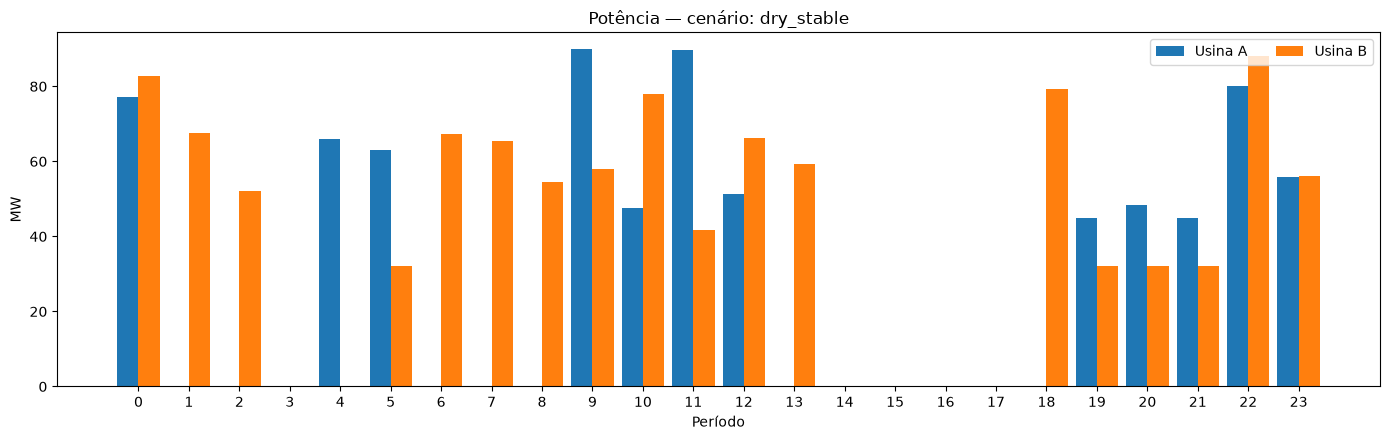

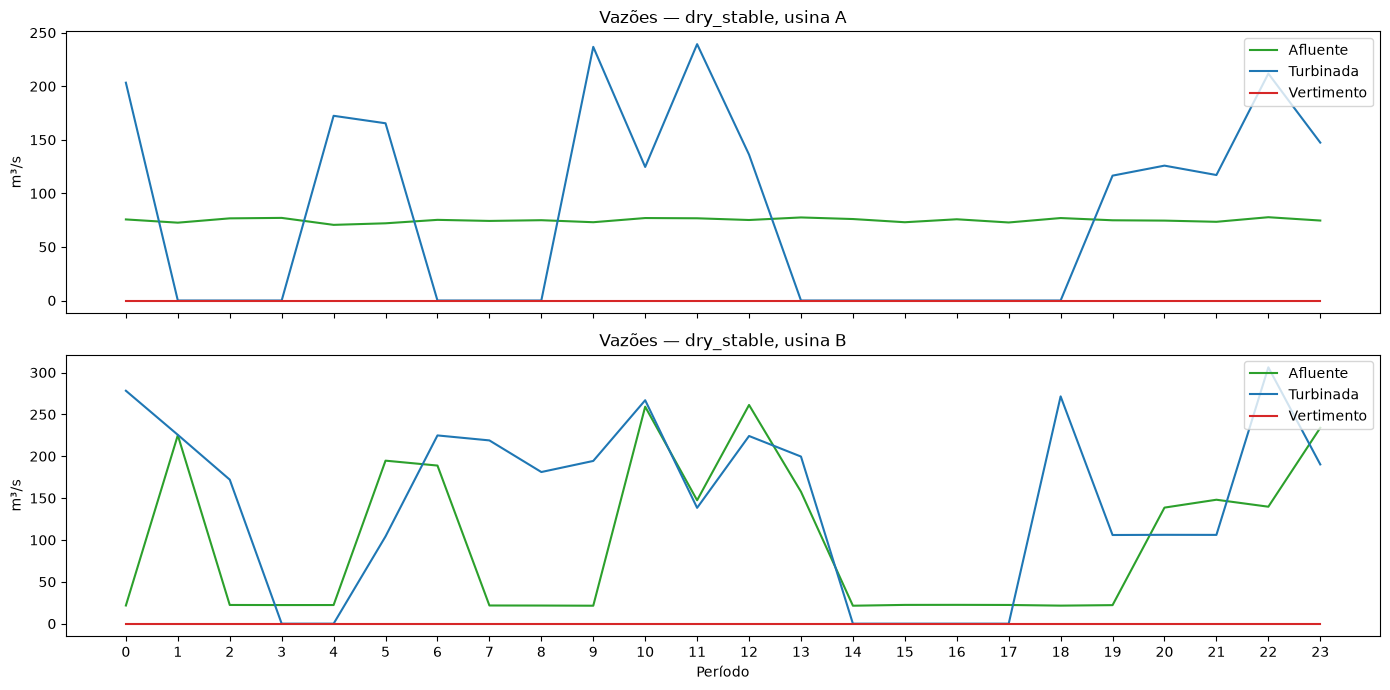

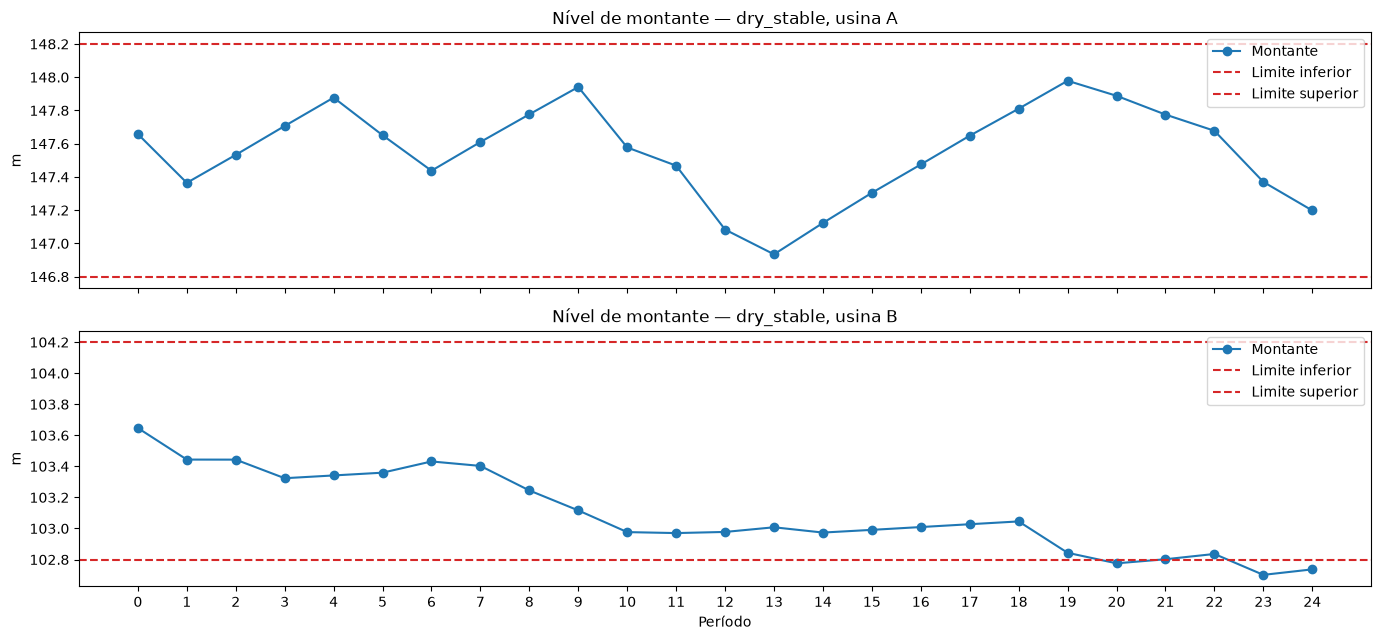

Análise gráfica: dry_variable

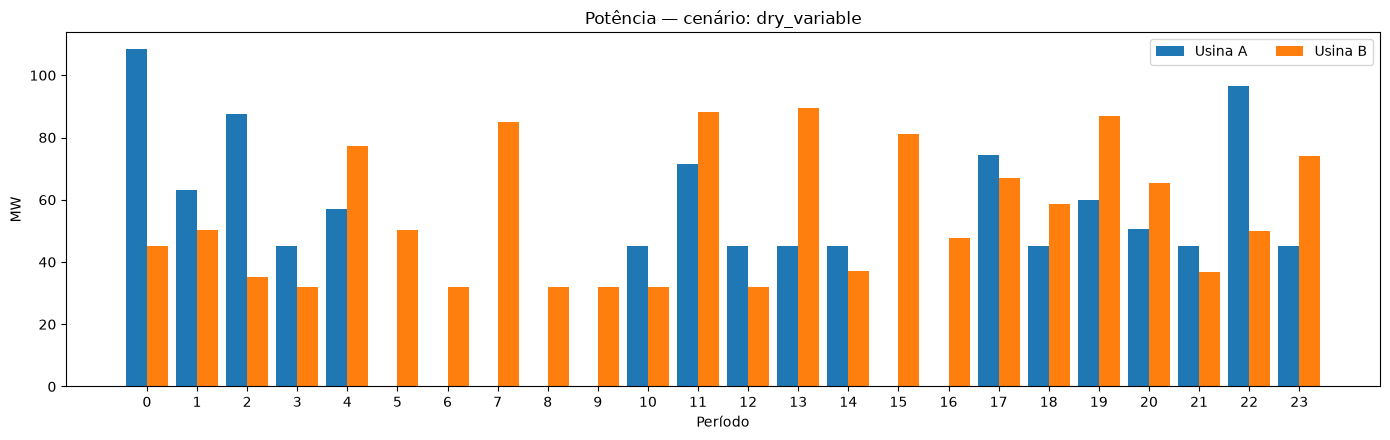

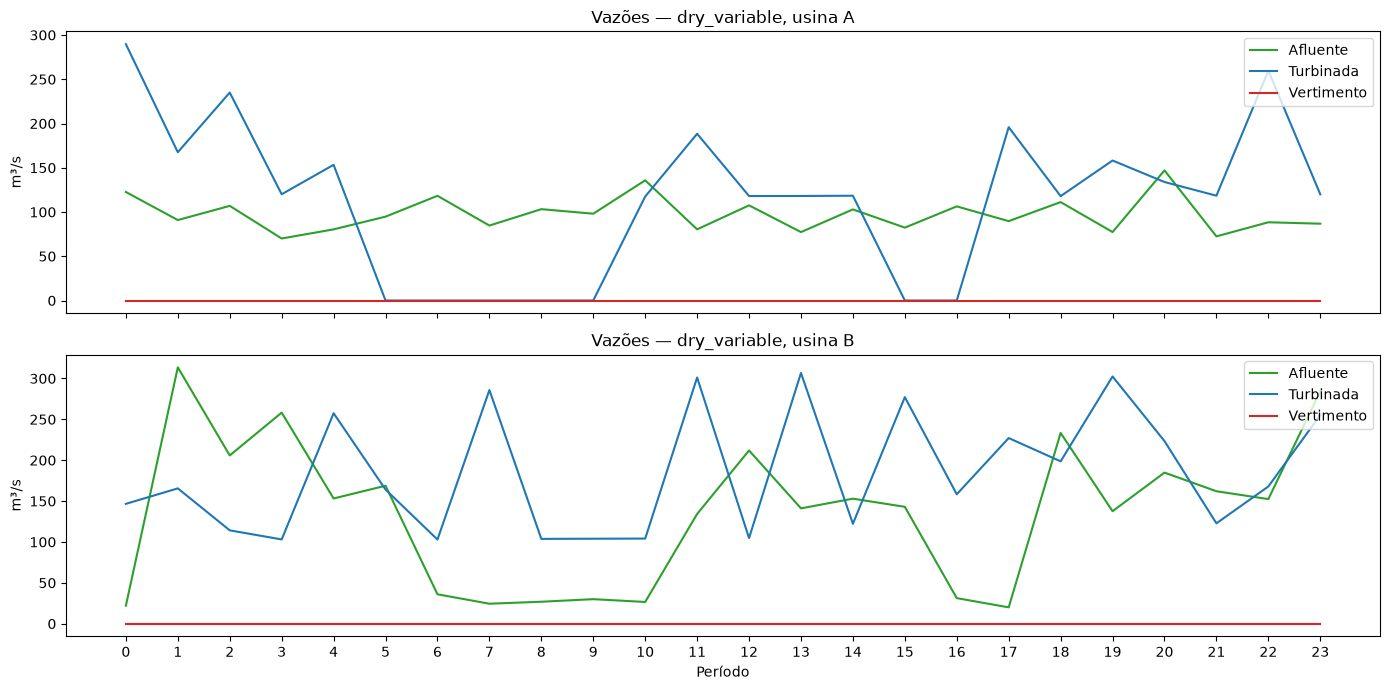

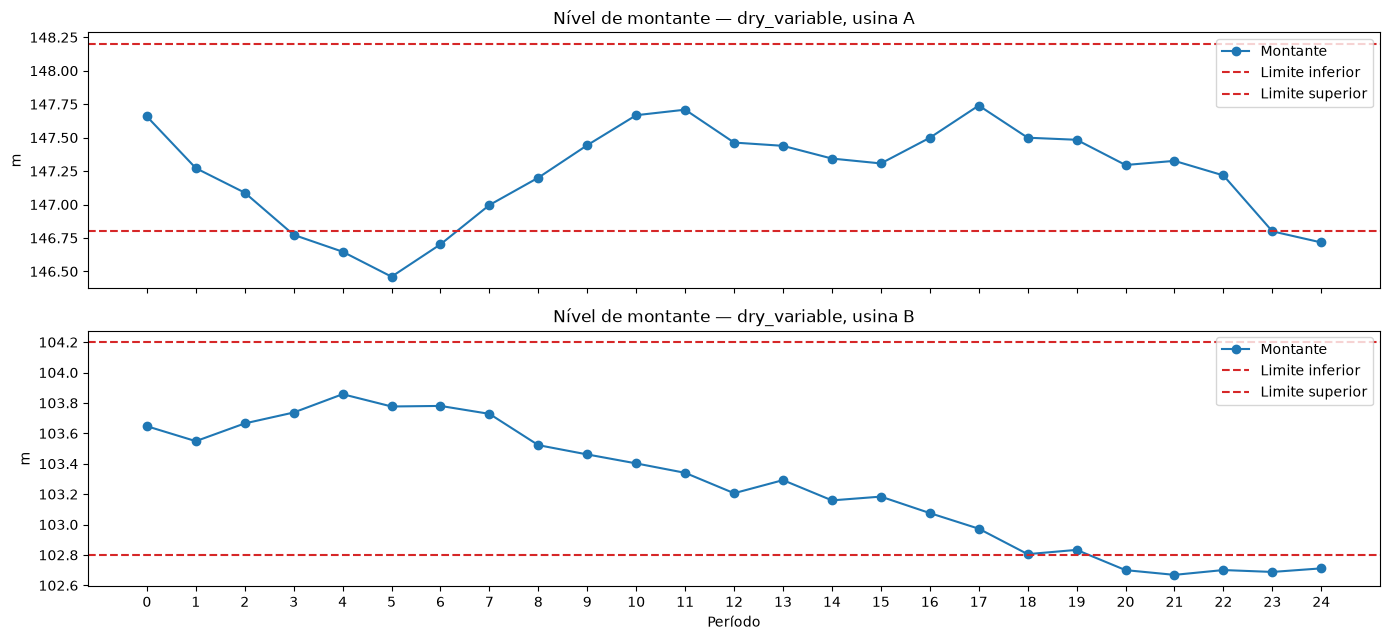

Análise gráfica: typical

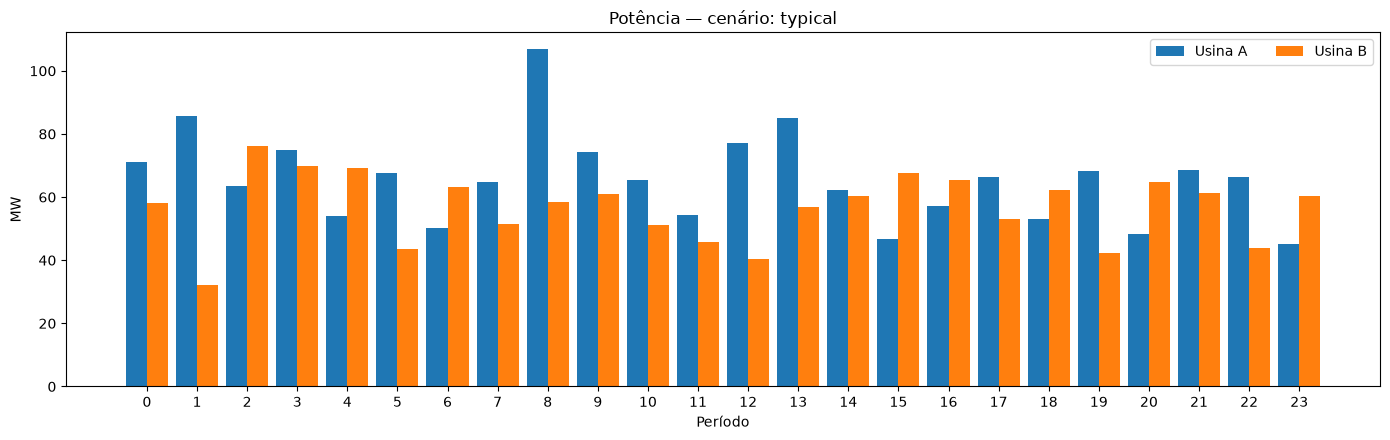

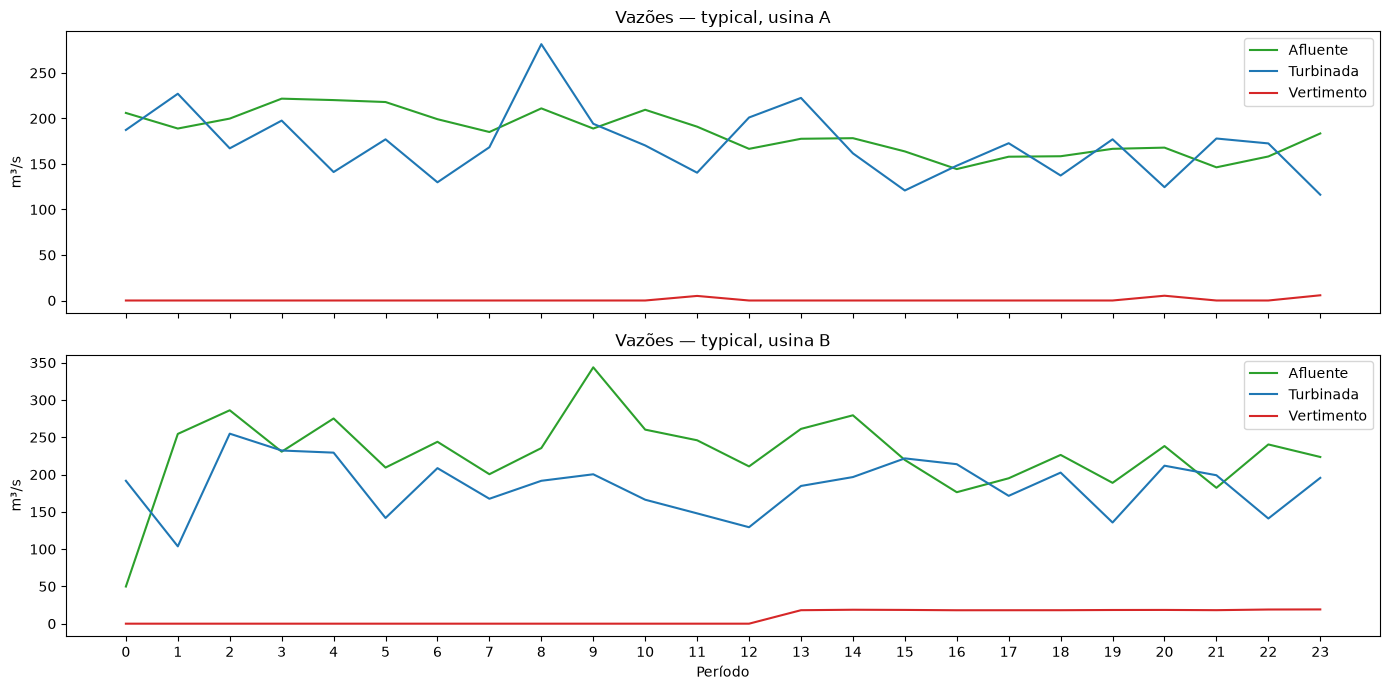

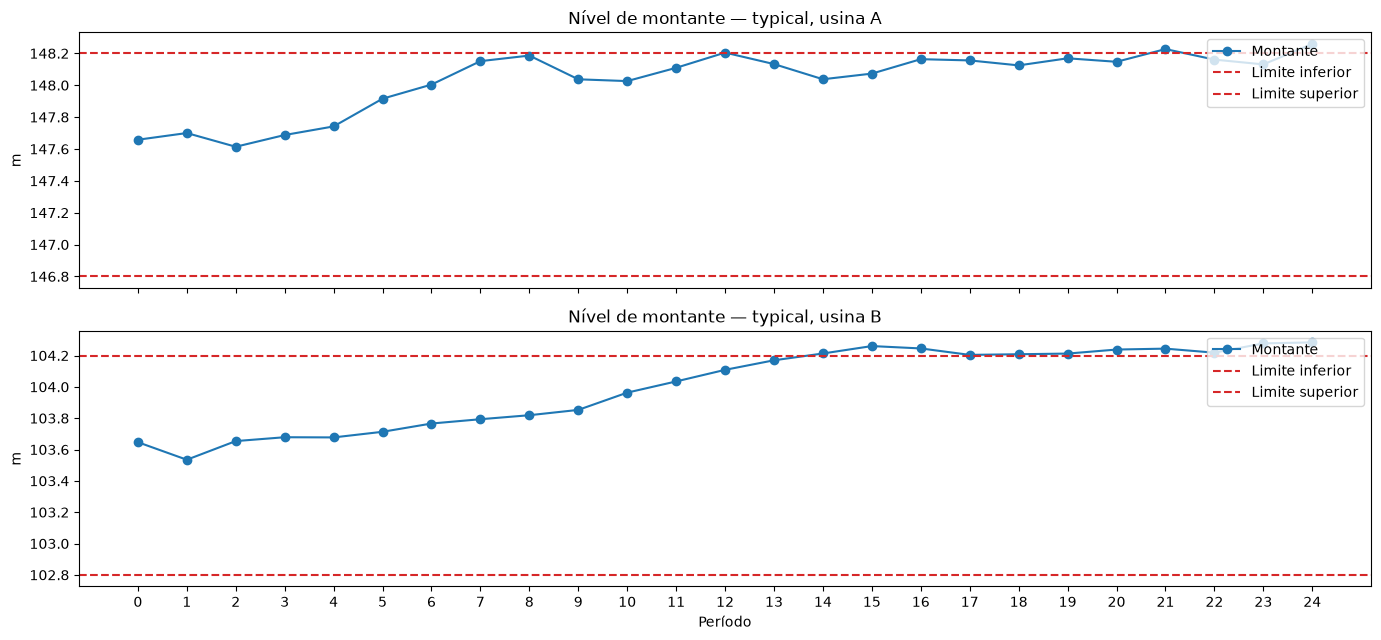

Análise gráfica: upstream_peak

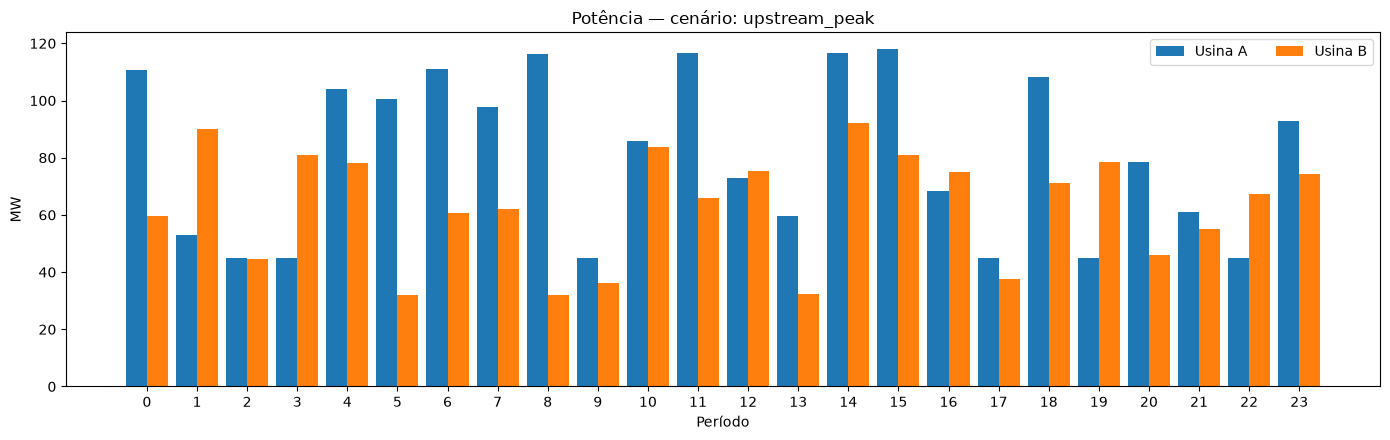

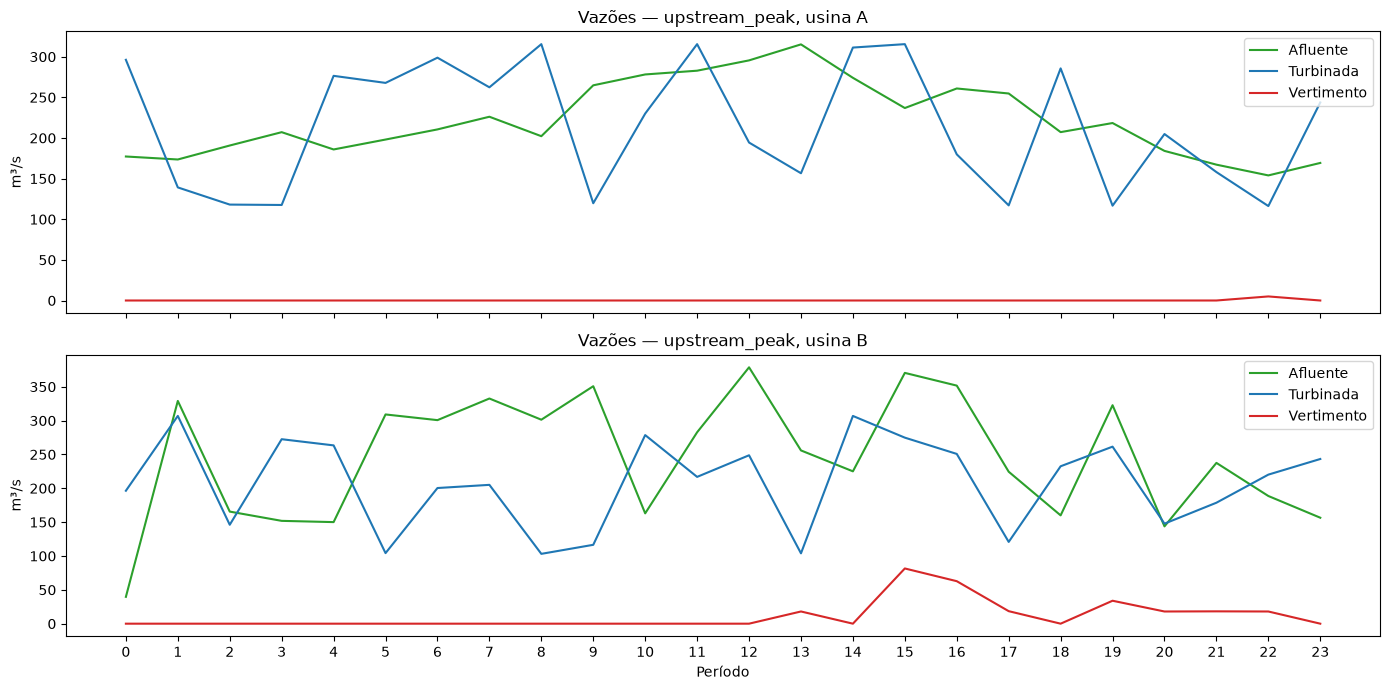

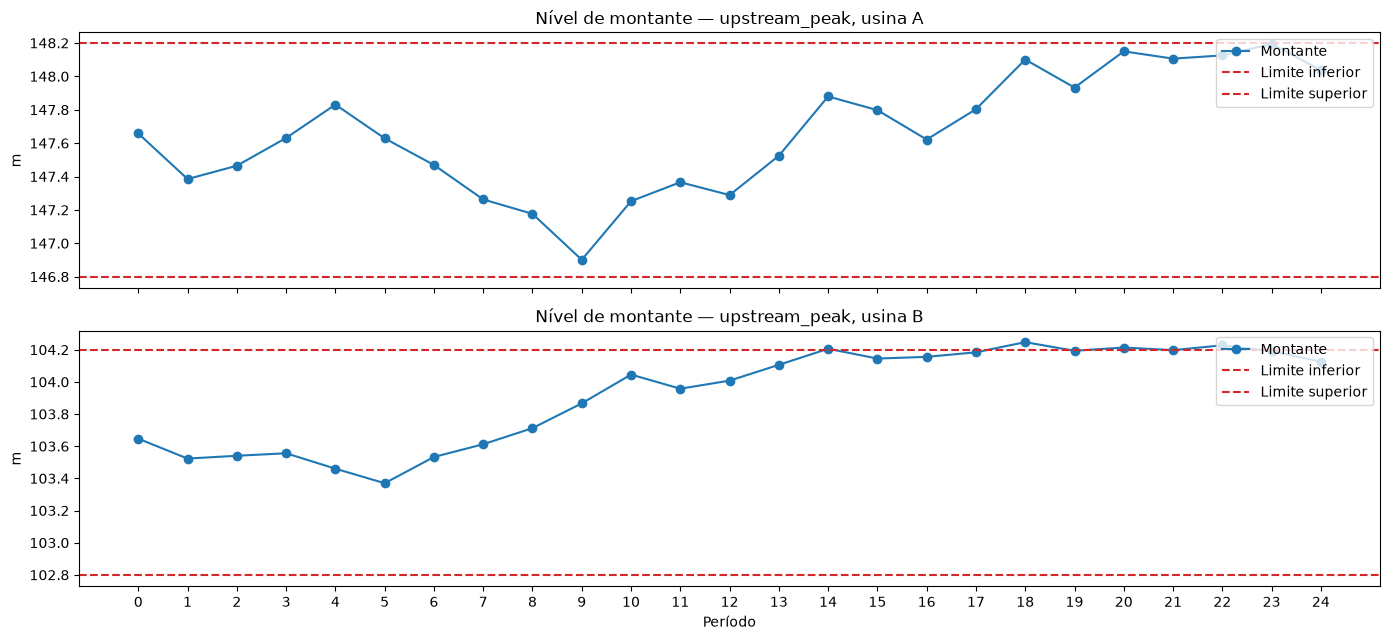

Análise gráfica: downstream_dominant

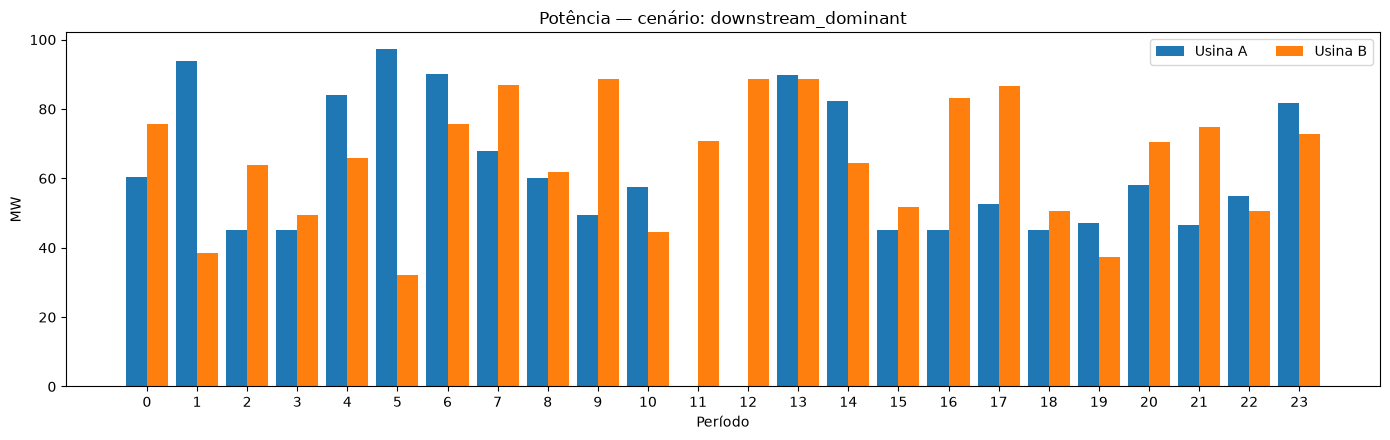

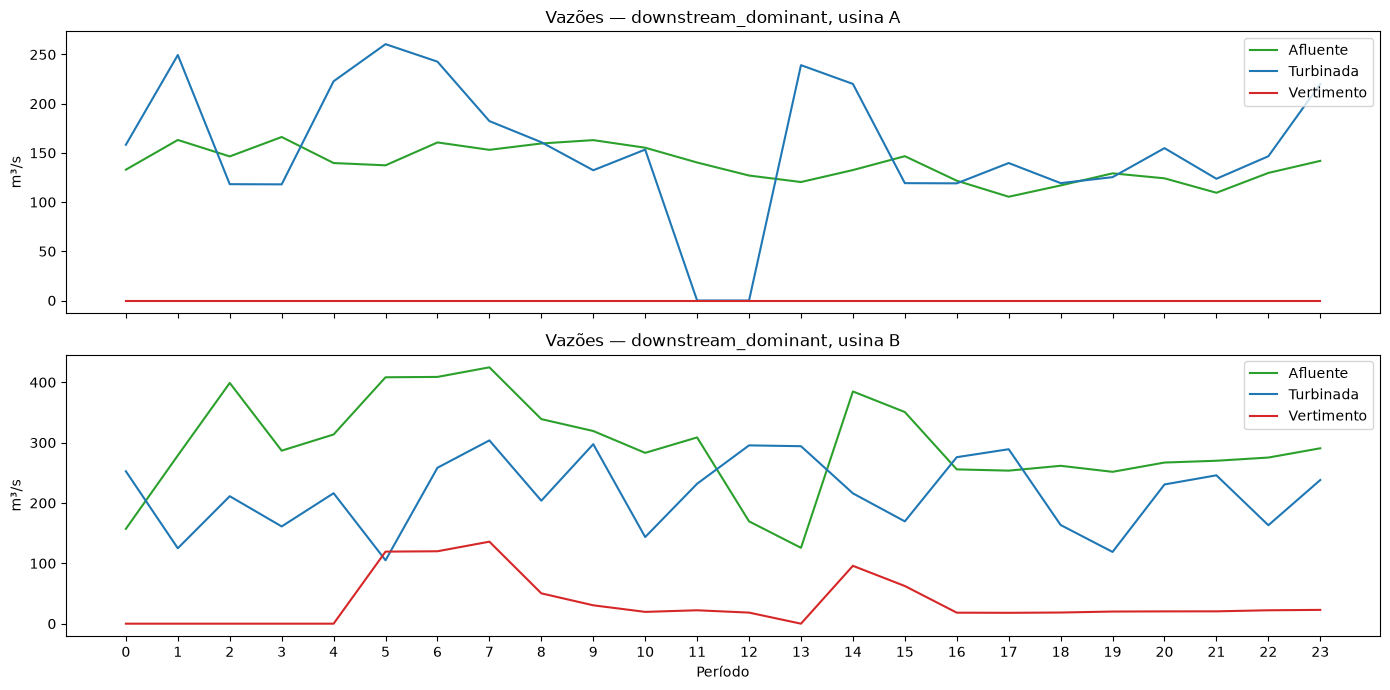

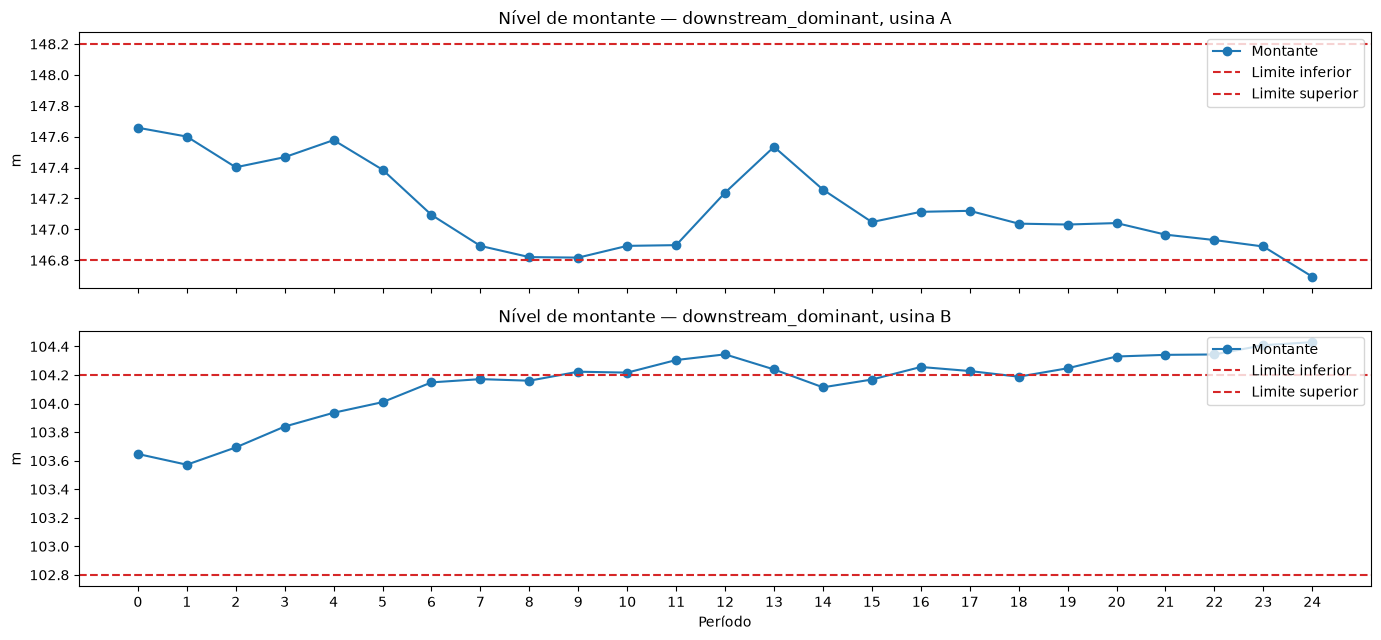

Análise gráfica: wet_rising

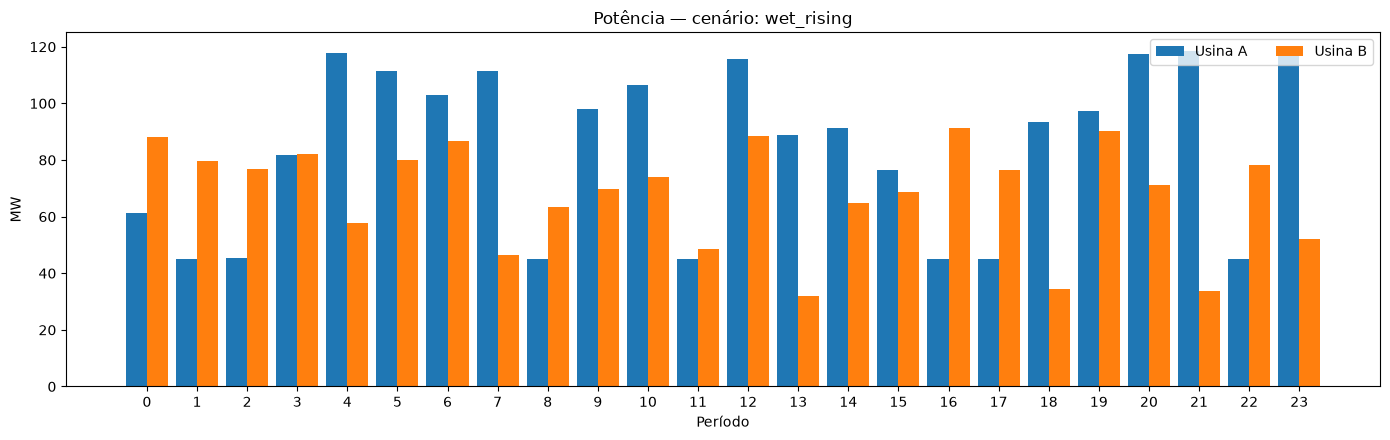

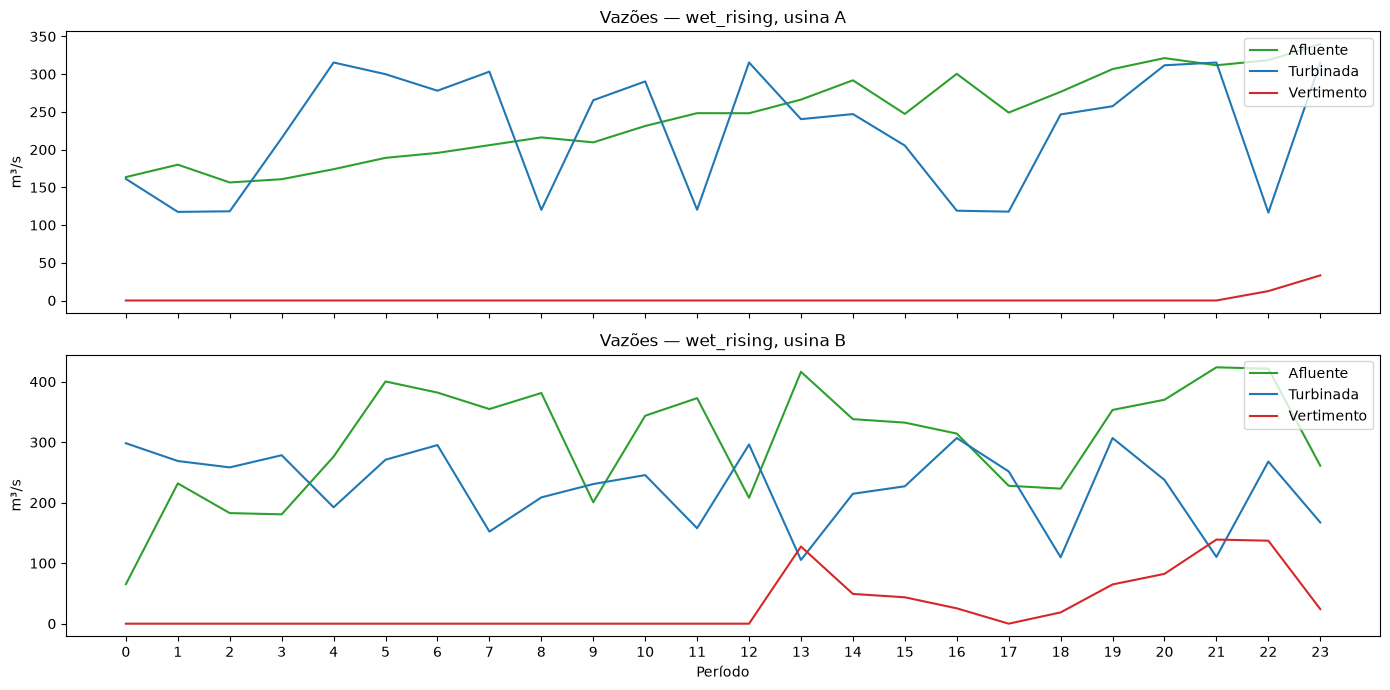

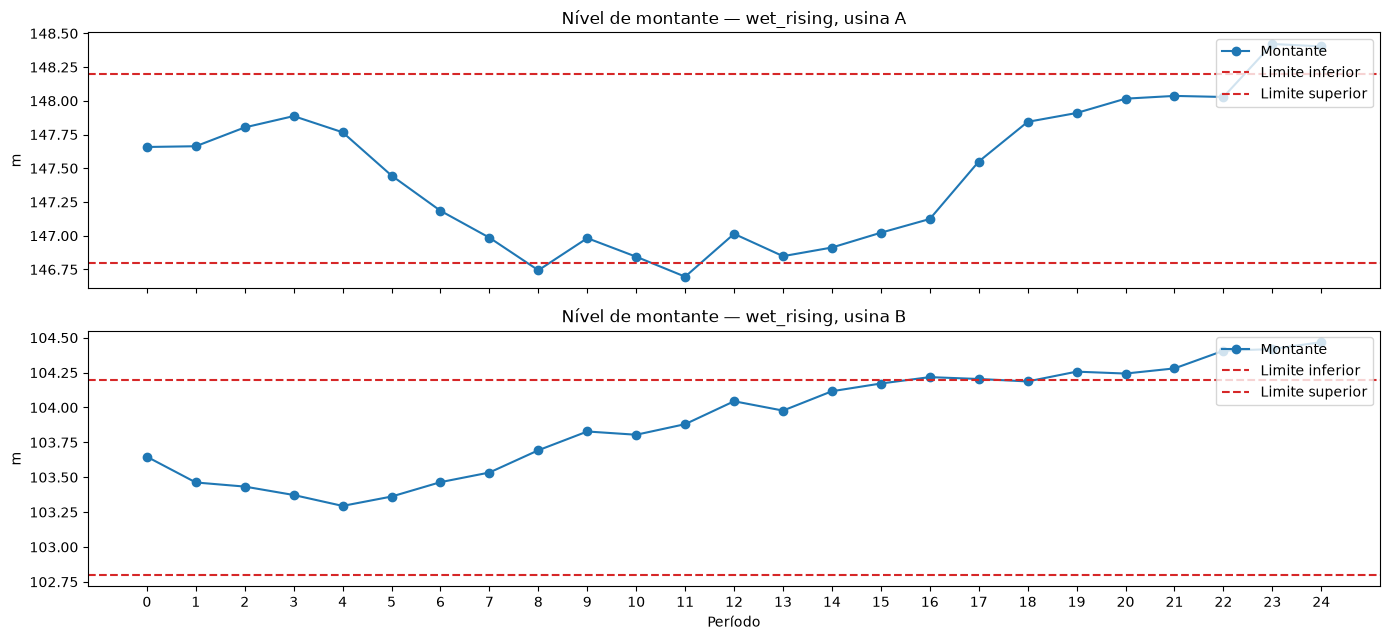

Análise gráfica: flood

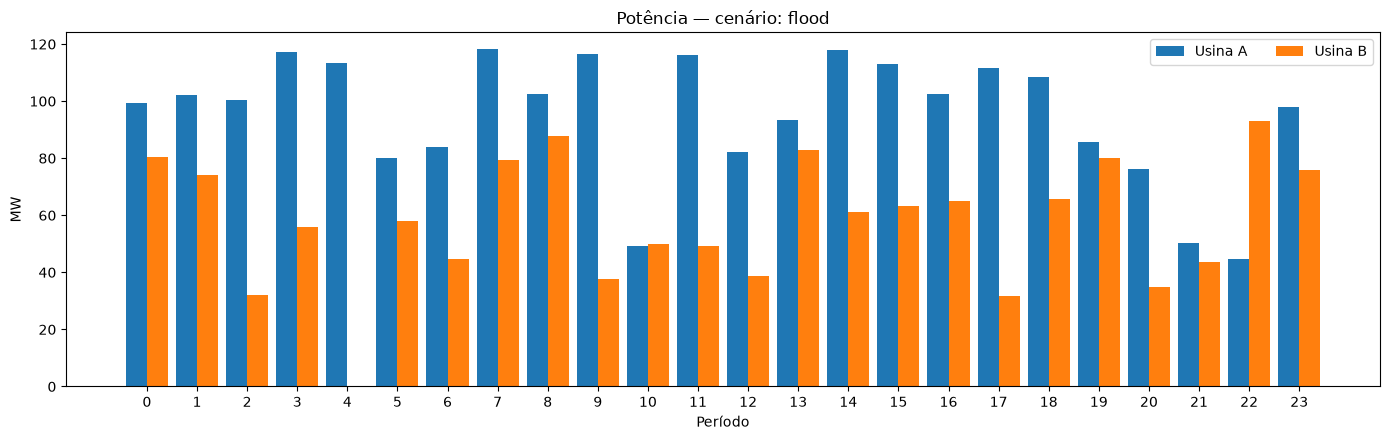

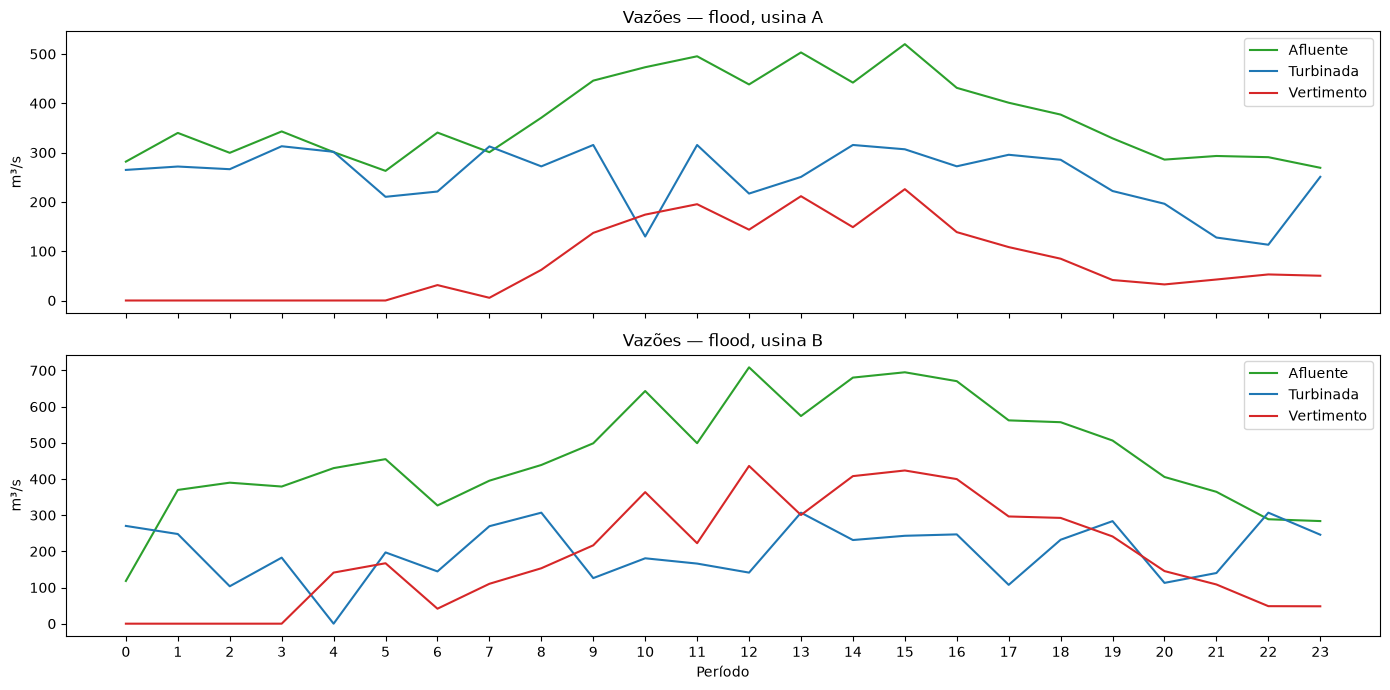

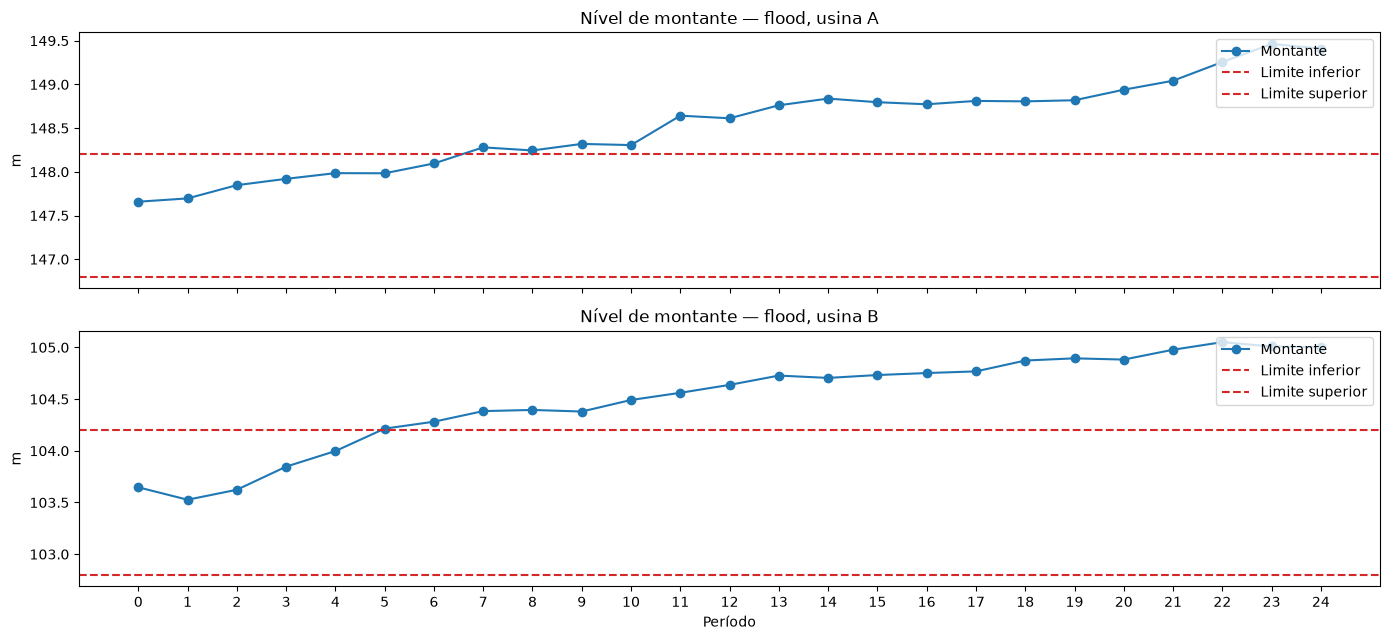

In [6]:
periods = list(range(cascade.periods))
level_periods = list(range(cascade.periods + 1))
plant_a, plant_b = cascade.plants
PERIOD_LABEL = "Período"
UPPER_RIGHT_LABEL = "upper right"
bar_width = 0.42

for scenario_name, scenario_result in results.items():
    display(Markdown(f"Análise gráfica: {scenario_name}"))

    fig, axis = plt.subplots(figsize=(14, 4.5))
    axis.bar(
        [period - bar_width / 2 for period in periods],
        scenario_result.power_mw[0],
        width=bar_width,
        label="Usina A",
        color="#1f77b4",
    )
    axis.bar(
        [period + bar_width / 2 for period in periods],
        scenario_result.power_mw[1],
        width=bar_width,
        label="Usina B",
        color="#ff7f0e",
    )
    axis.set(
        title=f"Potência — cenário: {scenario_name}",
        xlabel=PERIOD_LABEL,
        ylabel="MW",
        xticks=periods,
    )
    axis.legend(loc=UPPER_RIGHT_LABEL, ncols=2)
    fig.tight_layout()

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    for axis, plant_index, plant in zip(axes, (0, 1), (plant_a, plant_b), strict=True):
        axis.plot(
            periods,
            scenario_result.total_inflow_m3s[plant_index],
            label="Afluente",
            color="#2ca02c",
        )
        axis.plot(
            periods,
            scenario_result.turbine_flow_m3s[plant_index],
            label="Turbinada",
            color="#1f77b4",
        )
        axis.plot(
            periods,
            scenario_result.spill_flow_m3s[plant_index],
            label="Vertimento",
            color="#d62728",
        )
        axis.set(title=f"Vazões — {scenario_name}, usina {plant.name}", ylabel="m³/s")
        axis.legend(loc=UPPER_RIGHT_LABEL)
    axes[-1].set(xlabel=PERIOD_LABEL, xticks=periods)
    fig.tight_layout()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
    for axis, plant_index, plant in zip(axes, (0, 1), (plant_a, plant_b), strict=True):
        axis.plot(
            level_periods,
            scenario_result.level_m[plant_index],
            marker="o",
            label="Montante",
            color="#1f77b4",
        )
        axis.axhline(
            plant.min_level_m, color="#d62728", linestyle="--", label="Limite inferior"
        )
        axis.axhline(
            plant.max_level_m, color="#d62728", linestyle="--", label="Limite superior"
        )
        axis.set(
            title=f"Nível de montante — {scenario_name}, usina {plant.name}", ylabel="m"
        )
        axis.legend(loc=UPPER_RIGHT_LABEL)
    axes[-1].set(xlabel=PERIOD_LABEL, xticks=level_periods)
    fig.tight_layout()
    plt.show()